In [87]:
import torch
import matplotlib.pyplot
import re
import lightning as L

In [88]:
import os
import string
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import lightning as L

CHARS = string.digits + string.ascii_uppercase  # "0123456789ABC...Z", 36 chars
BLANK = len(CHARS)                              # index 36 — blank / padding
NUM_CLASSES = len(CHARS) + 1                   # 37
MAX_LEN = 8
CHAR2IDX = {c: i for i, c in enumerate(CHARS)}

_TRAIN_TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
_VAL_TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class PlatesDataset(Dataset):
    def __init__(self, samples: list[tuple[str, str]], transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def _encode(self, label: str) -> torch.Tensor:
        seq = [CHAR2IDX.get(c, BLANK) for c in label[:MAX_LEN]]
        seq += [BLANK] * (MAX_LEN - len(seq))
        return torch.tensor(seq, dtype=torch.long)

    def __getitem__(self, idx):
        path, label_str = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self._encode(label_str)


class PlatesDataModule(L.LightningDataModule):
    def __init__(self, root: str = "plates_data_cropped", batch_size: int = 32,
                 val_split: float = 0.1, num_workers: int = 4):
        super().__init__()
        self.root = root
        self.batch_size = batch_size
        self.val_split = val_split
        self.num_workers = num_workers

    def setup(self, stage=None):
        all_samples = sorted(
            (str(p), p.stem.split("_")[-1].upper())
            for p in Path(self.root).rglob("*.jpg")
        )
        perm = torch.randperm(len(all_samples), generator=torch.Generator().manual_seed(42)).tolist()
        n_val = int(len(all_samples) * self.val_split)
        self.train_ds = PlatesDataset([all_samples[i] for i in perm[n_val:]], _TRAIN_TRANSFORM)
        self.val_ds   = PlatesDataset([all_samples[i] for i in perm[:n_val]],  _VAL_TRANSFORM)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size,
                          shuffle=True, num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers, pin_memory=True)


No pretrained weights exist for this model. Using random initialization.


Params: 1.8M
Output shape: torch.Size([1, 8, 37])


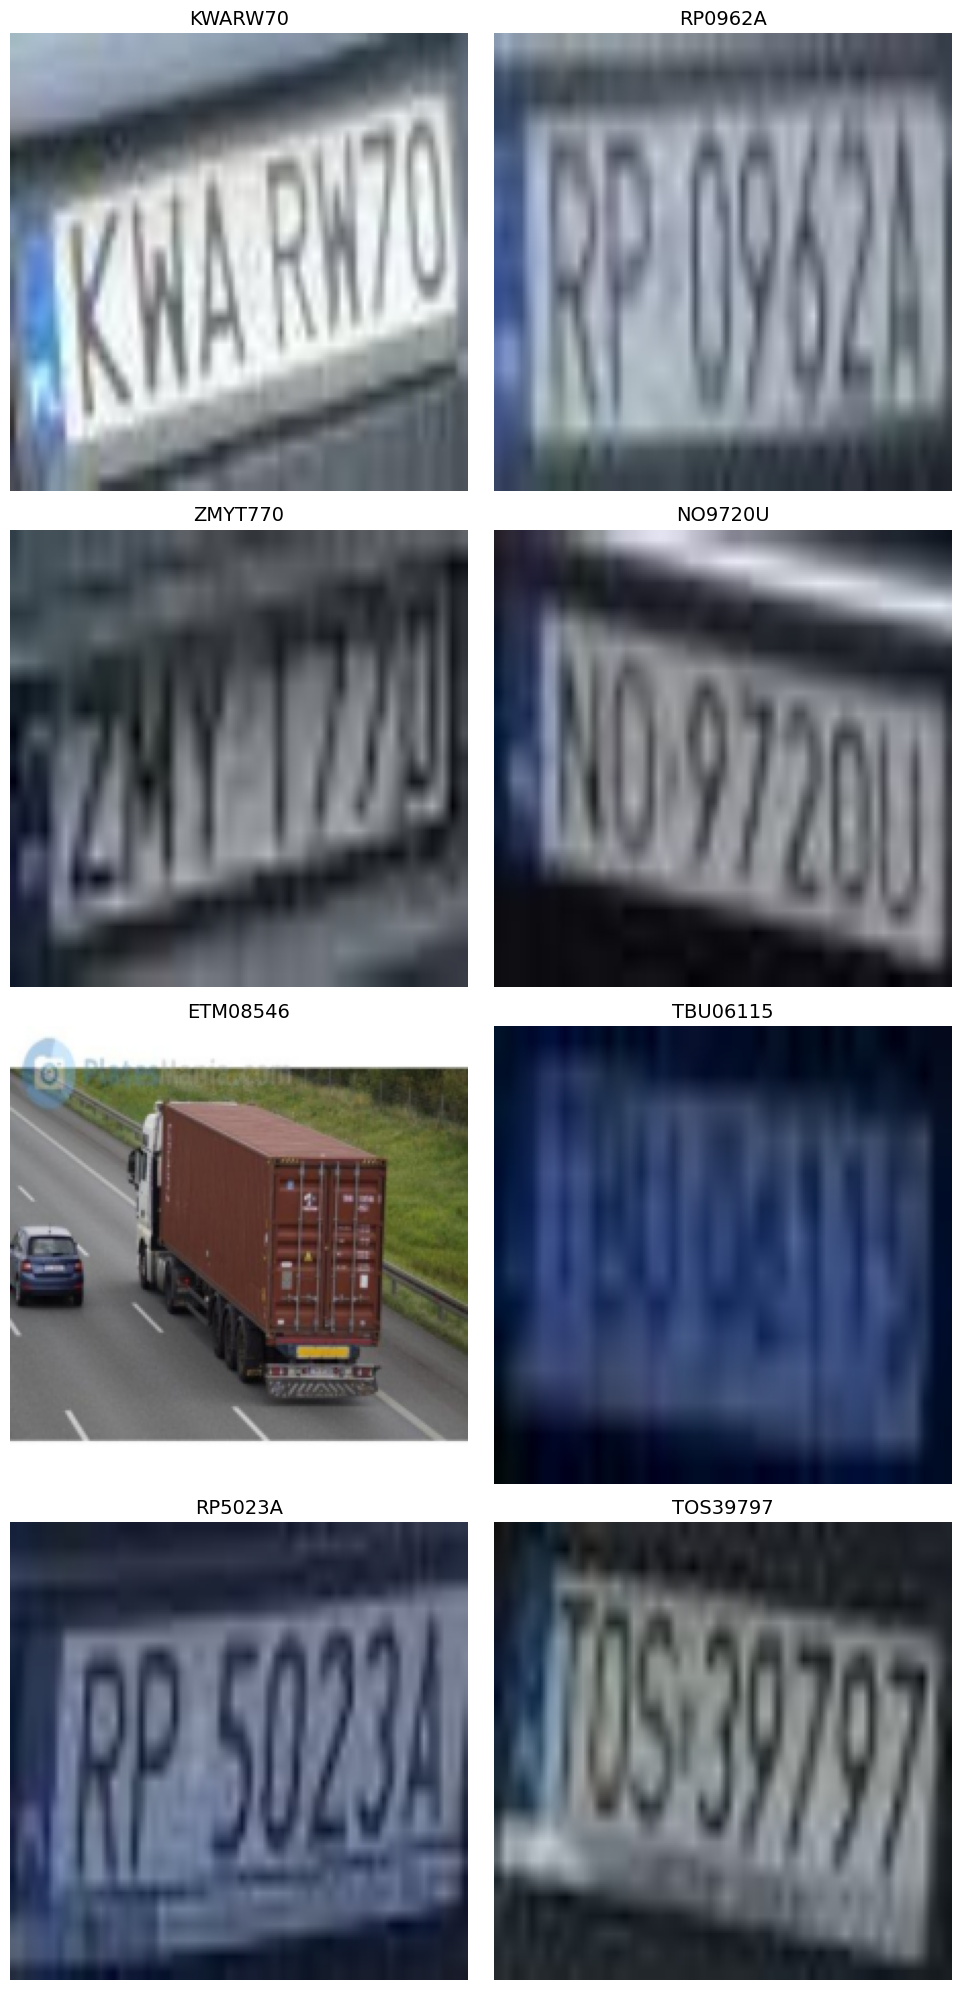

In [89]:
import timm
import torch.nn as nn
import matplotlib.pyplot as plt

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])


class PlateClassifier(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES, max_len: int = MAX_LEN):
        super().__init__()
        self.backbone = timm.create_model(
            "mobilenetv3_small_100",
            pretrained=True,
            num_classes=0,
            drop_rate=0.2,
        )
        self.dropout = nn.Dropout(0.2)
        self.head = nn.Linear(self.backbone.num_features, max_len * num_classes)
        self.max_len = max_len
        self.num_classes = num_classes

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.head(x)
        return x.view(-1, self.max_len, self.num_classes)  # (B, 8, 37)


model = PlateClassifier()
print(f"Params: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print(f"Output shape: {model(torch.zeros(1, 3, 224, 224)).shape}")

IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}

def _decode(t):
    return "".join(IDX2CHAR.get(i.item(), "") for i in t if i.item() != BLANK)

_dm = PlatesDataModule(batch_size=16)
_dm.setup()
_imgs, _labels = next(iter(_dm.val_dataloader()))

fig, axes = plt.subplots(4, 2, figsize=(10, 20))
for ax, img, lbl in zip(axes.flatten(), _imgs, _labels):
    rgb = (img.permute(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1).numpy()
    ax.imshow(rgb)
    ax.set_title(_decode(lbl), fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [90]:
from lightning.pytorch.loggers import CometLogger
from ultralytics import YOLO as UltralyticsYOLO
from torchvision.ops import roi_align

comet_logger = CometLogger(
    api_key=os.environ.get("COMET_API_KEY"),
    project="plate-recognition",
    name="MobileNetV3-2.5M",
)


class PlateModule(L.LightningModule):
    def __init__(self, lr: float = 1e-3, weight_decay: float = 1e-4, unfreeze_epoch: int = 3):
        super().__init__()
        self.model = PlateClassifier()

        _yolo_wrapper = UltralyticsYOLO('./yolo_best.pt')
        self.yolo = _yolo_wrapper.model.float()
        for m in self.yolo.modules():
            if hasattr(m, 'export'):
                m.export = True

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

        self.lr = lr
        self.weight_decay = weight_decay
        self.unfreeze_epoch = unfreeze_epoch
        self.loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

        for p in self.model.backbone.parameters():
            p.requires_grad = False

    def forward(self, x):                                    # [1, 3, 640, 640] float32 NCHW [0-255]
        det  = self.yolo(x / 255.0)                         # [1, 300, 6]  x1 y1 x2 y2 conf cls

        best = det[0, :, 4].argmax()
        x1, y1 = det[0, best, 0], det[0, best, 1]
        x2, y2 = det[0, best, 2], det[0, best, 3]

        rois    = torch.stack([x.new_zeros(()), x1, y1, x2, y2]).unsqueeze(0)   # [1, 5]
        cropped = roi_align(x, rois, output_size=(224, 224), spatial_scale=1.0) # [1, 3, 224, 224]

        normalized = (cropped / 255.0 - self.mean) / self.std
        chars    = self.model(normalized)                    # [1, 8, 37]
        best_box = torch.stack([x1, y1, x2, y2]).unsqueeze(0)  # [1, 4]

        return best_box, chars

    def on_train_epoch_start(self):
        if self.current_epoch == self.unfreeze_epoch:
            for p in self.model.backbone.parameters():
                p.requires_grad = True

    def _step(self, batch):
        imgs, labels = batch
        logits = self.model(imgs)
        loss = self.loss_fn(logits.permute(0, 2, 1), labels)
        preds = logits.argmax(-1)
        char_acc  = (preds == labels).float().mean()
        plate_acc = (preds == labels).all(dim=-1).float().mean()
        return loss, char_acc, plate_acc

    def training_step(self, batch, _):
        loss, char_acc, plate_acc = self._step(batch)
        self.log_dict({"train/loss": loss, "train/char_acc": char_acc, "train/plate_acc": plate_acc},
                      prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, _):
        loss, char_acc, plate_acc = self._step(batch)
        self.log_dict({"val/loss": loss, "val/char_acc": char_acc, "val/plate_acc": plate_acc},
                      prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            opt,
            max_lr=self.lr,
            total_steps=self.trainer.estimated_stepping_batches,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}


dm = PlatesDataModule(batch_size=64)
module = PlateModule(lr=3e-3)

# trainer = L.Trainer(
#     max_epochs=200,
#     accelerator="auto",
#     precision="16-mixed",
#     logger=comet_logger,
# )

# trainer.fit(module, dm)

COMET INFO: An experiment with the same configuration options is already running and will be reused.
No pretrained weights exist for this model. Using random initialization.


In [91]:
model_state_dict = torch.load('model.pt')
module.model.load_state_dict( model_state_dict )

<All keys matched successfully>

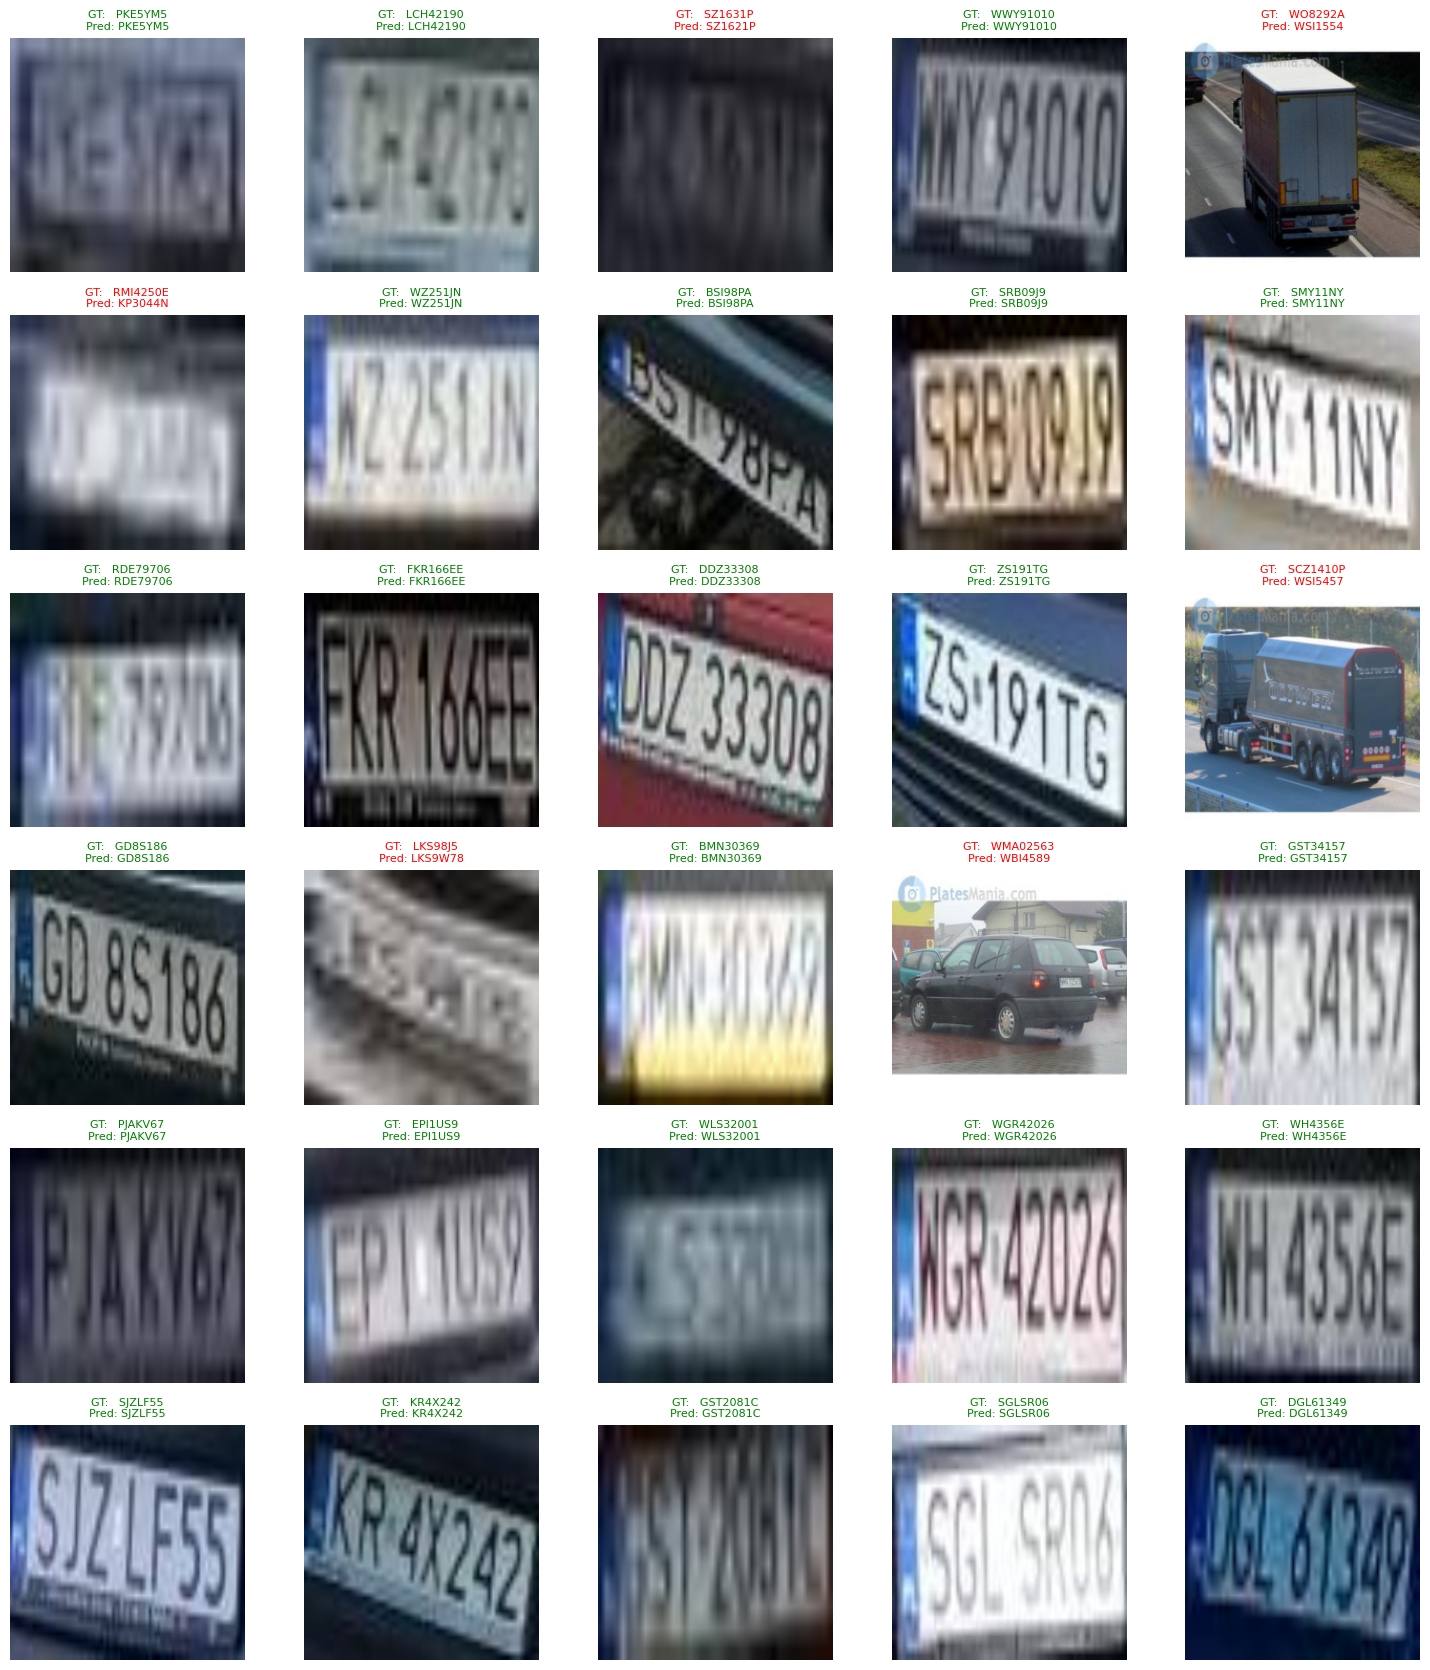

In [92]:
import matplotlib.pyplot as plt

IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def decode(indices: torch.Tensor) -> str:
    return "".join(IDX2CHAR.get(i.item(), "") for i in indices if i.item() != BLANK)

def show_predictions(model, datamodule, n: int = 30):
    device = next(model.parameters()).device
    model.eval()

    datamodule.setup()
    loader = DataLoader(datamodule.val_ds, batch_size=n, shuffle=True)
    imgs, labels = next(iter(loader))

    with torch.no_grad():
        logits = model(imgs.to(device))        # (n, MAX_LEN, NUM_CLASSES)
    preds = logits.argmax(-1).cpu()            # (n, MAX_LEN)

    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.8))
    axes = axes.flatten()

    for i in range(n):
        img = imgs[i].permute(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN
        img = img.clamp(0, 1).numpy()

        gt   = decode(labels[i])
        pred = decode(preds[i])
        match = pred == gt

        axes[i].imshow(img)
        axes[i].set_title(f"GT:   {gt}\nPred: {pred}", fontsize=8,
                          color="green" if match else "red")
        axes[i].axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(module.model, dm)


In [93]:
# torch.save(module.model.state_dict(), "model.pt")

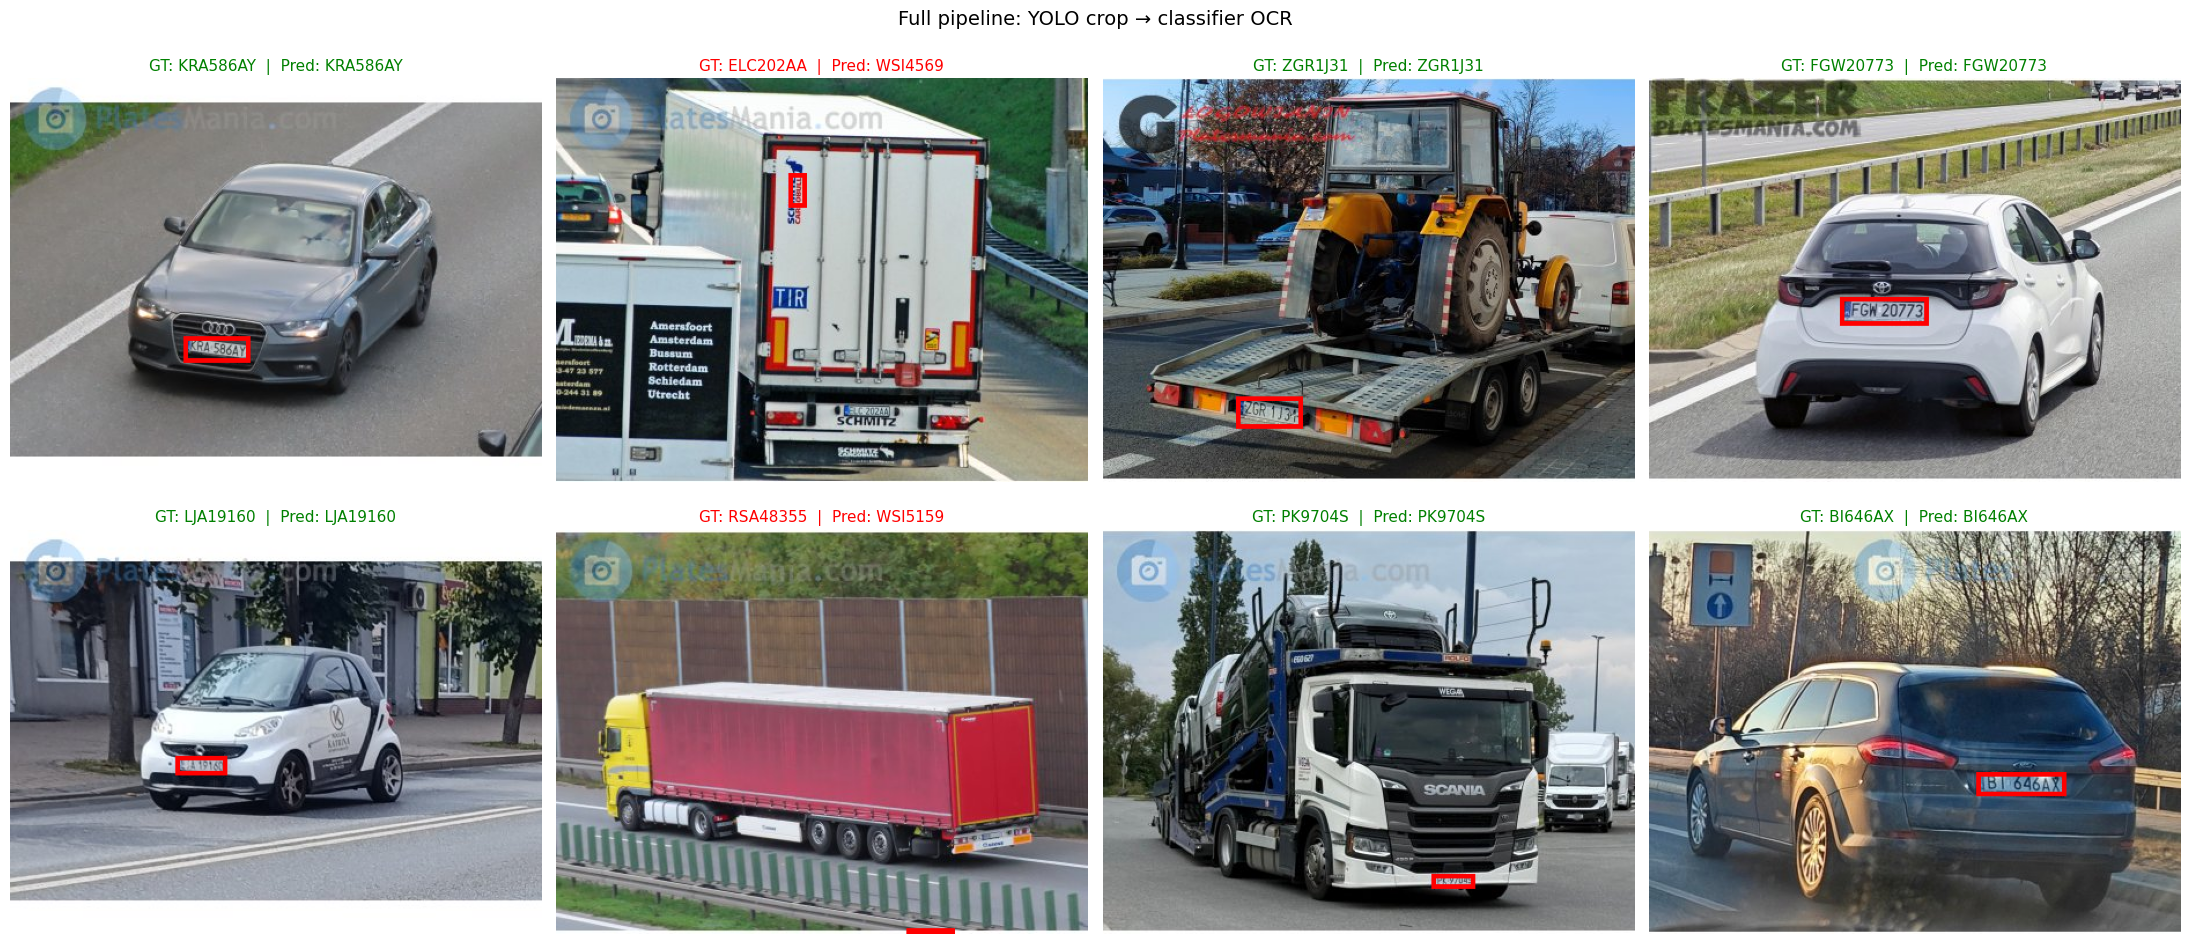

In [94]:
import glob, random
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

random.seed(42)
_paths = random.sample(glob.glob("plates_data/**/*.jpg", recursive=True), 8)

module.model.load_state_dict(torch.load('model.pt', map_location='cpu'))
module.eval()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for ax, path in zip(axes.flatten(), _paths):
    gt   = Path(path).stem.split("_")[-1].upper()
    img  = Image.open(path).convert("RGB")
    w, h = img.size
    img640 = img.resize((640, 640))

    x = torch.from_numpy(np.array(img640)).permute(2, 0, 1).float().unsqueeze(0)  # [1,3,640,640] [0-255]

    with torch.no_grad():
        best_box, chars = module(x)

    pred = "".join(IDX2CHAR.get(i.item(), "") for i in chars.argmax(-1).squeeze(0) if i.item() != BLANK)

    x1, y1, x2, y2 = best_box[0].tolist()
    draw = ImageDraw.Draw(img)
    draw.rectangle([x1 * w/640, y1 * h/640, x2 * w/640, y2 * h/640], outline="red", width=4)

    ax.imshow(img)
    ax.set_title(f"GT: {gt}  |  Pred: {pred}", fontsize=11,
                 color="green" if pred == gt else "red")
    ax.axis("off")

for ax in axes.flatten()[len(_paths):]:
    ax.axis("off")

plt.suptitle("Full pipeline: YOLO crop → classifier OCR", fontsize=14)
plt.tight_layout()
plt.show()

In [97]:
import torch, shutil

module.model.load_state_dict(torch.load('model.pt', map_location='cpu'))
module.eval()

torch.onnx.export(
    module,
    torch.zeros(1, 3, 640, 640),
    "model.onnx",
    dynamo=False,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["images"],
    output_names=["output0", "output1"],
    dynamic_axes={"images": {0: "batch_size"}, "output1": {0: "batch_size"}},
)

_dst = "object_detection/android/app/src/main/assets/model.onnx"
shutil.copy("model.onnx", _dst)
print(f"Exported and copied to {_dst}")

/tmp/ipykernel_23429/3026279513.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported and copied to object_detection/android/app/src/main/assets/model.onnx
